In [1]:
from pandas.tseries.offsets import BDay
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from tqdm import tqdm
try:
    import pyfolio as pf
except ImportError:
    import pyfolio_reloaded as pf


/opt/anaconda3/lib/python3.13/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


## Using ML for Portfolio Factors Strategy

From a pool of stocks, we run XGBoost regression on a backtest window with start and end dates.

In [2]:
# ----------------------------
# 1. Parameters
# ----------------------------
tickers = [
    "AAPL","MSFT","GOOG","AMZN","TSLA",
    "META","NVDA","NFLX","AMD","INTC",
    "JPM","BAC","WFC","GS","MS",
    "XOM","CVX","JNJ","PFE","UNH",
    "KO","PEP","MCD","WMT","COST",
    "HD","LOW","DIS","CRM","ORCL"
]





In [3]:
# feature / label windows
prediction_horizon = 20
train_window = 252  
transaction_cost = 0.001


In [4]:
import pandas as pd
file_path = '/Users/wdy/Downloads/market_data.xlsx'
prices = pd.read_excel(file_path, sheet_name='prices', index_col=0, parse_dates=True)
volume = pd.read_excel(file_path, sheet_name='volume', index_col=0, parse_dates=True)
benchmark = pd.read_excel(file_path, sheet_name='benchmark', index_col=0, parse_dates=True)

prices.index.name = 'Date'
volume.index.name = 'Date'
benchmark.index.name = 'Date'


In [5]:


returns = prices.pct_change()




Compute the features - momentum and volatility to use as predictors. These are very elementary for now. The predictors need to be changed here.

In [6]:
# ----------------------------
# 3. Compute richer features and pooled panel dataset
# FIXED VERSION FOR EMPTY PANEL (UPDATED FEATURES)
# ----------------------------

import numpy as np
import pandas as pd

daily_ret = prices.pct_change()


curr_price = prices.shift(1)


mom_5 = prices.pct_change(5).shift(1)
mom_20 = prices.pct_change(20).shift(1)
mom_60 = prices.pct_change(60).shift(1)


ma_5 = prices.rolling(5).mean().shift(1) / curr_price - 1.0
ma_20 = prices.rolling(20).mean().shift(1) / curr_price - 1.0
ma_60 = prices.rolling(60).mean().shift(1) / curr_price - 1.0

max_5 = prices.rolling(5).max().shift(1) / curr_price - 1.0
max_20 = prices.rolling(20).max().shift(1) / curr_price - 1.0
max_60 = prices.rolling(60).max().shift(1) / curr_price - 1.0

min_5 = prices.rolling(5).min().shift(1) / curr_price - 1.0
min_20 = prices.rolling(20).min().shift(1) / curr_price - 1.0
min_60 = prices.rolling(60).min().shift(1) / curr_price - 1.0





vol_5 = daily_ret.rolling(5).std().shift(1)
vol_20 = daily_ret.rolling(20).std().shift(1)
vol_60 = daily_ret.rolling(60).std().shift(1)


avg_vol_5 = volume.rolling(5).mean().shift(1)
avg_vol_20 = volume.rolling(20).mean().shift(1)
avg_vol_60 = volume.rolling(60).mean().shift(1)


vol_ratio_5_60 = avg_vol_5 / (avg_vol_60 + 1e-8)
vol_ratio_20_60 = avg_vol_20 / (avg_vol_60 + 1e-8)

# future return target
future_returns = prices.pct_change(prediction_horizon).shift(-prediction_horizon)

# build pooled panel
panel_frames = []
for ticker in tickers:
    df = pd.DataFrame({
        "date": prices.index,
        "ticker": ticker,

        "mom_5": mom_5[ticker],
        "mom_20": mom_20[ticker],
        "mom_60": mom_60[ticker],

        "ma_5": ma_5[ticker], "ma_20": ma_20[ticker], "ma_60": ma_60[ticker],
        "max_5": max_5[ticker], "max_20": max_20[ticker], "max_60": max_60[ticker],
        "min_5": min_5[ticker], "min_20": min_20[ticker], "min_60": min_60[ticker],

        "vol_5": vol_5[ticker],
        "vol_20": vol_20[ticker],
        "vol_60": vol_60[ticker],
  
        "vol_ratio_5_60": vol_ratio_5_60[ticker],
        "vol_ratio_20_60": vol_ratio_20_60[ticker],
  
        "target_raw": future_returns[ticker],
    })
    panel_frames.append(df)

panel = pd.concat(panel_frames, ignore_index=True)
panel = panel.replace([np.inf, -np.inf], np.nan)
panel["date"] = pd.to_datetime(panel["date"]).dt.normalize()

panel["target_risk_adj"] = panel["target_raw"] / (panel["vol_20"] * np.sqrt(prediction_horizon) + 1e-8)

# cross-sectional standardisation
grp = panel.groupby("date")["target_risk_adj"]
panel["target"] = ((panel["target_risk_adj"] - grp.transform("mean")) /
                   (grp.transform("std") + 1e-8)).clip(-3, 3)

required_cols = [
    "mom_5", "mom_20", "mom_60",
    "ma_5", "ma_20", "ma_60",
    "max_5", "max_20", "max_60",
    "min_5", "min_20", "min_60",
    "vol_5", "vol_20", "vol_60",
    "vol_ratio_5_60", "vol_ratio_20_60",
    "target"
]
panel = panel.dropna(subset=required_cols).copy()

print("Panel rows:", len(panel))
print("Panel unique dates:", panel["date"].nunique())
print("Panel unique tickers:", panel["ticker"].nunique())
print("Panel date range:", panel["date"].min(), "to", panel["date"].max())

if panel.empty:
    raise ValueError("Panel is still empty after feature engineering. Check prices/volume download.")

panel_dates = pd.DatetimeIndex(sorted(panel["date"].unique()))
rebalance_dates = (
    pd.Series(panel_dates, index=panel_dates.to_period("M"))
    .groupby(level=0)
    .max()
    .tolist()
)

print("Number of rebalance dates:", len(rebalance_dates))
print("First 5 rebalance dates:", rebalance_dates[:5])
print("Last 5 rebalance dates:", rebalance_dates[-5:])

Panel rows: 72330
Panel unique dates: 2411
Panel unique tickers: 30
Panel date range: 2016-04-01 00:00:00 to 2025-10-30 00:00:00
Number of rebalance dates: 115
First 5 rebalance dates: [Timestamp('2016-04-29 00:00:00'), Timestamp('2016-05-31 00:00:00'), Timestamp('2016-06-30 00:00:00'), Timestamp('2016-07-29 00:00:00'), Timestamp('2016-08-31 00:00:00')]
Last 5 rebalance dates: [Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-08-29 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-30 00:00:00')]


In [7]:
# ----------------------------
# 4. Rolling pooled ML prediction
# ROBUST VERSION (With updated features, Early Stopping, and Fixed Look-ahead bias)
# ----------------------------
from xgboost import XGBRegressor
from tqdm import tqdm
import pandas as pd
import numpy as np  

print("Final rebalance date count before backtest:", len(rebalance_dates))

feature_cols = [
    "mom_5", "mom_20", "mom_60",
    "ma_5", "ma_20", "ma_60",
    "max_5", "max_20", "max_60",
    "min_5", "min_20", "min_60",
    "vol_5", "vol_20", "vol_60",
    "vol_ratio_5_60", "vol_ratio_20_60"
]

pred_rows = []
debug_counter = 0

all_trading_days = np.sort(panel["date"].unique())

for date in tqdm(rebalance_dates, desc="Monthly pooled ML backtest"):
    current_date_ts = pd.Timestamp(date).normalize()
    

    try:
        current_idx = np.where(all_trading_days == current_date_ts)[0][0]
    except IndexError:
        continue

    if current_idx <= prediction_horizon:
        continue
        
    train_end = all_trading_days[current_idx - prediction_horizon - 1]
    train_start = pd.Timestamp(train_end) - pd.Timedelta(days=train_window)

    train_df = panel[(panel["date"] >= train_start) & (panel["date"] <= train_end)].copy()
    test_df = panel[panel["date"] == current_date_ts].copy()

    train_df = train_df.dropna(subset=["target"]).copy()

    if debug_counter < 5:
        print(f"\nDate: {date}")
        print("train rows:", len(train_df))
        print("test rows:", len(test_df))
        print("test tickers:", test_df["ticker"].nunique())
        debug_counter += 1

    if test_df["ticker"].nunique() < 3 or len(train_df) == 0:
        continue

    train_dates = np.sort(train_df["date"].unique())
    
    if len(train_dates) <= prediction_horizon + 2:
        continue
        
    split_date_idx = int(len(train_dates) * 0.7)
    
    train_split_dates = train_dates[:split_date_idx]
    
    val_start_idx = split_date_idx + prediction_horizon
    if val_start_idx >= len(train_dates):
        continue  
        
    val_split_dates = train_dates[val_start_idx:]

    train_split = train_df[train_df["date"].isin(train_split_dates)]
    val_split = train_df[train_df["date"].isin(val_split_dates)]

    if len(train_split) == 0 or len(val_split) == 0:
        continue

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=20 
    )

    eval_set = [(val_split[feature_cols], val_split["target"])]
    
    model.fit(
        train_split[feature_cols], 
        train_split["target"],
        eval_set=eval_set,
        verbose=False 
    )

    test_df = test_df.copy()
    test_df["score"] = model.predict(test_df[feature_cols])

    pred_rows.append(test_df[["date", "ticker", "score", "vol_20"]])

if len(pred_rows) == 0:
    raise ValueError(
        "No prediction rows were generated. "
        "Look at the debug printouts above: train rows, test rows, and rebalance date count."
    )

pred_df = pd.concat(pred_rows, ignore_index=True)

predicted_signal = pred_df.pivot(index="date", columns="ticker", values="score").sort_index()
vol_for_weights = pred_df.pivot(index="date", columns="ticker", values="vol_20").sort_index()

print("Prediction rows:", len(pred_df))
print("Prediction dates:", predicted_signal.shape[0])
print("Prediction tickers:", predicted_signal.shape[1])

Final rebalance date count before backtest: 115


Monthly pooled ML backtest:   8%|█▏             | 9/115 [00:00<00:01, 65.03it/s]


Date: 2016-05-31 00:00:00
train rows: 630
test rows: 30
test tickers: 30

Date: 2016-06-30 00:00:00
train rows: 1290
test rows: 30
test tickers: 30

Date: 2016-07-29 00:00:00
train rows: 1890
test rows: 30
test tickers: 30

Date: 2016-08-31 00:00:00
train rows: 2580
test rows: 30
test tickers: 30

Date: 2016-09-30 00:00:00
train rows: 3210
test rows: 30
test tickers: 30


Monthly pooled ML backtest: 100%|█████████████| 115/115 [00:02<00:00, 46.19it/s]


Prediction rows: 3330
Prediction dates: 111
Prediction tickers: 30


In [8]:
weights = pd.DataFrame(0.0, index=predicted_signal.index, columns=predicted_signal.columns)

for date in predicted_signal.index:
    scores = predicted_signal.loc[date].dropna()
    if scores.empty:
        continue

    positive_scores = scores[scores > 0]
    
    longs = positive_scores.sort_values(ascending=False).head(10).index.tolist()

    if len(longs) == 0:
        continue

    equal_weight = 1.0 / len(longs)
    weights.loc[date, longs] = equal_weight


weights = weights.reindex(prices.index).ffill().shift(1).fillna(0.0)



print("Portfolio construction complete.")
print("Average daily leverage (should be <= 1.0):", weights.sum(axis=1).mean())




Portfolio construction complete.
Average daily leverage (should be <= 1.0): 0.9325842696629213


### Rationale of the backtest restuls
- On date of test, use the XGBoost model to find the relationship between the factors and the projected future return known on hindsight (for each stock).
- Sort the predicted return. Long the highest value and short the lowest value at the end of the month.
- At the next month, do the same and re-adjust the portfolio based on the long/short stocks.
![Backtest_Factors.png](attachment:ba29190d-289e-4fa3-b5d7-81a1b94693ab.png)


In [9]:

# ----------------------------
# 6. Apply transaction costs
# ----------------------------
weight_change = weights.diff().abs().sum(axis=1)
daily_returns = (weights * returns.fillna(0.0)).sum(axis=1)
daily_returns = daily_returns - weight_change * transaction_cost

benchmark = benchmark.fillna(0.0)
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
benchmark = benchmark.reindex(daily_returns.index).fillna(0.0)
start_date = "2018-01-01"
daily_returns = daily_returns.loc[daily_returns.index >= start_date]
benchmark = benchmark.loc[benchmark.index >= start_date]


### Portfolio Backtest Results

Note the backtest results are based on daily returns, although rebalancing is done monthly. This means the returns are not all realised. (but unrealised)

/opt/anaconda3/lib/python3.13/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25.639%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-02
End date,2025-11-28
Total months,94
,Backtest
Annual return,25.639%
Cumulative returns,505.87%
Annual volatility,23.911%
Sharpe ratio,1.07
Calmar ratio,0.86
Stability,0.96
Max drawdown,-29.974%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,29.97,2020-02-19,2020-03-16,2020-07-10,103
1,27.99,2022-01-03,2022-06-17,2023-01-26,279
2,23.95,2018-10-01,2018-12-24,2019-03-11,116
3,20.62,2025-01-30,2025-05-14,NaT,NaN
4,15.27,2018-01-29,2018-04-02,2018-08-06,136


/opt/anaconda3/lib/python3.13/site-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
/opt/anaconda3/lib/python3.13/site-packages/pyfolio/tears.py:1005: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


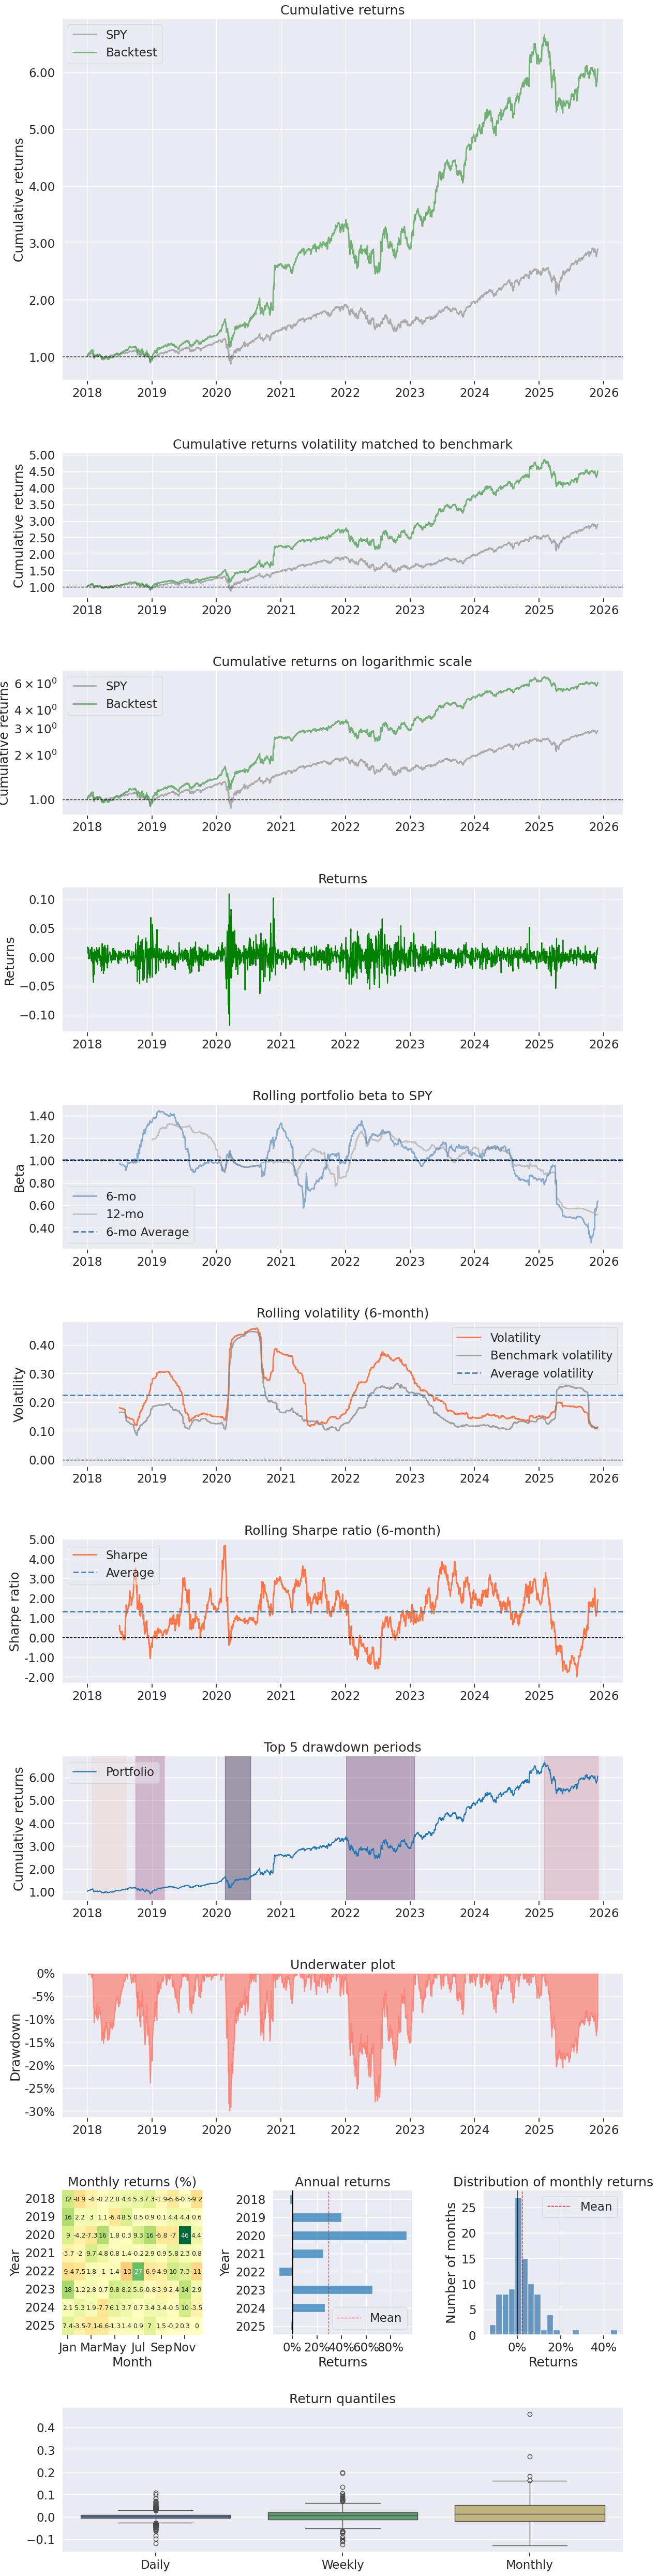

In [10]:
# ----------------------------
# 7. PyFolio analysis
# ----------------------------
# remove the initial 60 days lookback period
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
pf.create_full_tear_sheet(daily_returns.squeeze(), benchmark_rets=benchmark.squeeze())


### Comments on strategy
- The strategy outperformed the S\&P 500 index over the whole period. Although it must be noted that most of the gains occured in the year 2025.
- DUring the second half of 2024, the strategy did not do well, and fell almost 28% which took almost 4-5 months to recover.

### Exercise
- As part of the exercise, how will you improve the strategy?
    - Use more stocks
    - Do over a longer period of time for more robustness in results
    - Use another ML method.
    - Use a more stringent filter (with more stocks availability)
    - Use only long strategy (stocks) as a constraint.
    - Use other features (fundamentals eg) Note though these data available on a quarterly basis.
